# 04 Cross Document Similarity Analysis

**Project:** Insurance Fraud Detection Assistant

**Notebook:** `04-cross-document-similarity-analysis.ipynb`

In [1]:
# ==========================================
# Notebook 04
# Cross Document Similarity Analysis
# ==========================================

import pandas as pd
import numpy as np

from sentence_transformers import SentenceTransformer

from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
import seaborn as sns

d:\Books\projects-nlp-transformers-learning\.projectnlps\Lib\site-packages\sentence_transformers\cross_encoder\CrossEncoder.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


In [2]:
claims_df = pd.read_csv("../data/insurance_claims.csv")

In [3]:
claims_df.head()

,claim_id,claimant_name,vehicle_vin,mechanic_shop,clinic_name,lawyer,claimant_statement,police_report,adjuster_notes,medical_bill,fraud_label
0,CLM001,Wendy Holland,FqH15433919443,Rapid Auto Repair,Care First Clinic,Smith & Associates,A vehicle rear-ended me while I was waiting at...,Witnesses confirmed another driver caused the ...,Section international though many movement.,5072,0
1,CLM002,Douglas Lara,acF49501195178,Rapid Auto Repair,Wellness Recovery Center,Anderson Legal,The vehicle changed lanes unexpectedly and hit...,Police observed damage consistent with reporte...,Budget Mrs part spend middle threat smile incr...,1541,0
2,CLM003,Chloe Murphy,xeQ24677572737,Rapid Auto Repair,Care First Clinic,Justice Partners,I was stopped at a red light when another vehi...,Accident report indicates claimant followed tr...,Similar never box line.,20226,1
3,CLM004,Jodi Reynolds MD,sPL40843321198,Rapid Auto Repair,Wellness Recovery Center,Justice Partners,The vehicle changed lanes unexpectedly and hit...,Police observed damage consistent with reporte...,Section season nor political bank.,7723,0
4,CLM005,Elizabeth Patel,mmr35740163797,Prime Vehicle Repair,Wellness Recovery Center,Smith & Associates,I was driving through an intersection when ano...,Witnesses confirmed another driver caused the ...,Kind compare across audience society.,23376,0


In [4]:
embedding_model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")

In [5]:
claim_text = """
I was stopped at a red light when another vehicle hit me.
"""

In [6]:
police_text = """
Police report indicates claimant was travelling at 55 mph.
"""

In [7]:
claim_emb = embedding_model.encode(claim_text)

police_emb = embedding_model.encode(police_text)

In [9]:
similarity = cosine_similarity(claim_emb.reshape(1, -1), police_emb.reshape(1, -1))[0][
    0
]
similarity

0.3836525

In [10]:
print(f"Similarity: {similarity:.4f}")

Similarity: 0.3837


In [11]:
discrepancy = 1 - similarity

discrepancy

0.6163474917411804

In [12]:
def calculate_similarity(text_a, text_b, model):

    emb_a = model.encode(text_a)

    emb_b = model.encode(text_b)

    score = cosine_similarity(emb_a.reshape(1, -1), emb_b.reshape(1, -1))[0][0]

    return float(score)

In [13]:
def discrepancy_score(text_a, text_b, model):

    similarity = calculate_similarity(text_a, text_b, model)

    return 1 - similarity

In [14]:
calculate_similarity(claim_text, police_text, embedding_model)

0.3836525082588196

In [15]:
discrepancy_score(claim_text, police_text, embedding_model)

0.6163474917411804

In [16]:
cross_document_results = []

In [17]:
for _, row in claims_df.iterrows():

    similarity = calculate_similarity(
        row["claimant_statement"], row["police_report"], embedding_model
    )

    discrepancy = 1 - similarity

    cross_document_results.append(
        {
            "claim_id": row["claim_id"],
            "similarity": similarity,
            "discrepancy": discrepancy,
            "fraud_label": row["fraud_label"],
        }
    )

In [19]:
results_df = pd.DataFrame(cross_document_results)

In [20]:
results_df.head()

,claim_id,similarity,discrepancy,fraud_label
0,CLM001,0.464861,0.535139,0
1,CLM002,0.514360,0.485640,0
2,CLM003,0.492316,0.507684,1
3,CLM004,0.514360,0.485640,0
4,CLM005,0.567865,0.432135,0


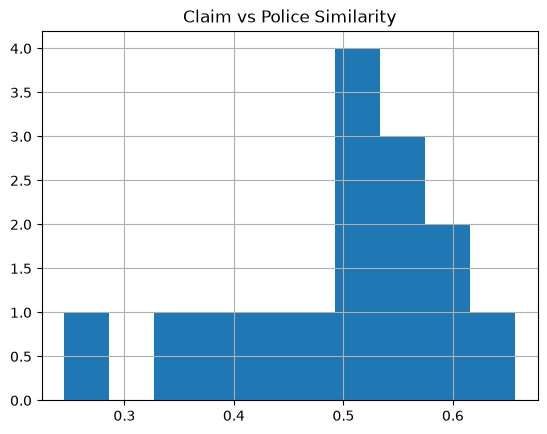

In [21]:
results_df["similarity"].hist(bins=10)

plt.title("Claim vs Police Similarity")

plt.show()

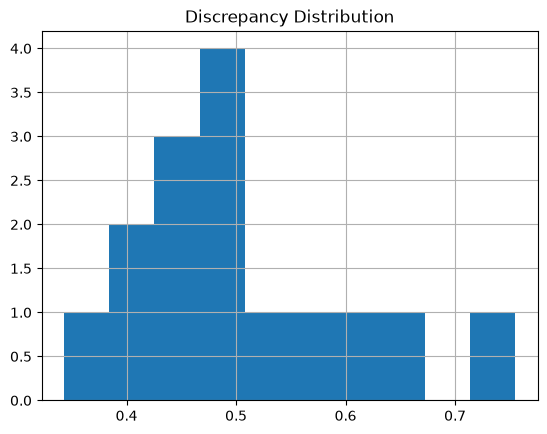

In [22]:
results_df["discrepancy"].hist(bins=10)

plt.title("Discrepancy Distribution")

plt.show()

In [23]:
results_df.groupby("fraud_label")["similarity"].mean()

fraud_label
0    0.502673
1    0.490411
Name: similarity, dtype: float64

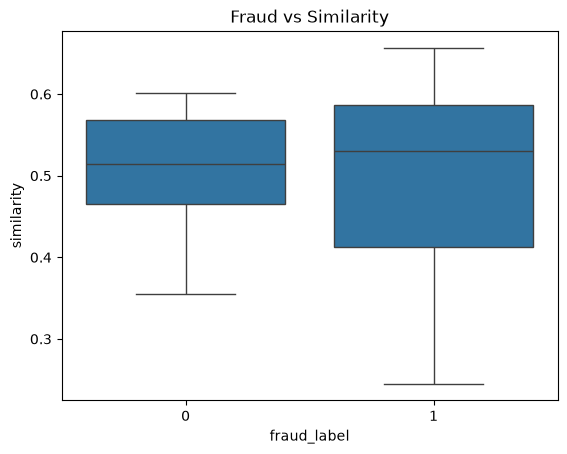

In [24]:
sns.boxplot(data=results_df, x="fraud_label", y="similarity")

plt.title("Fraud vs Similarity")

plt.show()

In [25]:
SIMILARITY_THRESHOLD = 0.60

In [26]:
SIMILARITY_THRESHOLD = 0.60

In [27]:
results_df["fraud_flag"] = results_df["similarity"] < SIMILARITY_THRESHOLD

In [28]:
results_df.head()

,claim_id,similarity,discrepancy,fraud_label,fraud_flag
0,CLM001,0.464861,0.535139,0,True
1,CLM002,0.514360,0.485640,0,True
2,CLM003,0.492316,0.507684,1,True
3,CLM004,0.514360,0.485640,0,True
4,CLM005,0.567865,0.432135,0,True


In [29]:
flagged_claims = results_df[results_df["fraud_flag"]]

In [30]:
flagged_claims

,claim_id,similarity,discrepancy,fraud_label,fraud_flag
0,CLM001,0.464861,0.535139,0,True
1,CLM002,0.514360,0.485640,0,True
2,CLM003,0.492316,0.507684,1,True
3,CLM004,0.514360,0.485640,0,True
4,CLM005,0.567865,0.432135,0,True
5,CLM006,0.386818,0.613182,1,True
6,CLM007,0.354559,0.645441,0,True
8,CLM009,0.593498,0.406502,1,True
9,CLM010,0.567865,0.432135,1,True
10,CLM011,0.245118,0.754882,1,True


In [31]:
for claim_id in flagged_claims["claim_id"]:

    print("=" * 80)

    claim = claims_df[claims_df["claim_id"] == claim_id]

    print("Claim ID:", claim_id)

    print()

    print("Claimant Statement:")

    print(claim["claimant_statement"].values[0])

    print()

    print("Police Report:")

    print(claim["police_report"].values[0])

    print("\n")

Claim ID: CLM001

Claimant Statement:
A vehicle rear-ended me while I was waiting at a traffic signal.

Police Report:
Witnesses confirmed another driver caused the accident.


Claim ID: CLM002

Claimant Statement:
The vehicle changed lanes unexpectedly and hit my car.

Police Report:
Police observed damage consistent with reported collision.


Claim ID: CLM003

Claimant Statement:
I was stopped at a red light when another vehicle hit me.

Police Report:
Accident report indicates claimant followed traffic rules.


Claim ID: CLM004

Claimant Statement:
The vehicle changed lanes unexpectedly and hit my car.

Police Report:
Police observed damage consistent with reported collision.


Claim ID: CLM005

Claimant Statement:
I was driving through an intersection when another vehicle struck my car.

Police Report:
Witnesses confirmed another driver caused the accident.


Claim ID: CLM006

Claimant Statement:


My neck and lower back experienced severe pain immediately after impact.

The collis

In [32]:
results_df[["claim_id", "similarity", "discrepancy"]]

,claim_id,similarity,discrepancy
0,CLM001,0.464861,0.535139
1,CLM002,0.514360,0.485640
2,CLM003,0.492316,0.507684
3,CLM004,0.514360,0.485640
4,CLM005,0.567865,0.432135
5,CLM006,0.386818,0.613182
6,CLM007,0.354559,0.645441
7,CLM008,0.656849,0.343151
8,CLM009,0.593498,0.406502
9,CLM010,0.567865,0.432135


In [33]:
high_risk = results_df.sort_values(by="discrepancy", ascending=False)

In [34]:
high_risk.head()

,claim_id,similarity,discrepancy,fraud_label,fraud_flag
10,CLM011,0.245118,0.754882,1,True
6,CLM007,0.354559,0.645441,0,True
5,CLM006,0.386818,0.613182,1,True
13,CLM014,0.433616,0.566384,0,True
0,CLM001,0.464861,0.535139,0,True


In [35]:
def risk_category(similarity):

    if similarity >= 0.80:

        return "Low Risk"

    elif similarity >= 0.60:

        return "Medium Risk"

    return "High Risk"

In [36]:
results_df["risk_level"] = results_df["similarity"].apply(risk_category)

In [37]:
results_df[["claim_id", "similarity", "risk_level"]]

,claim_id,similarity,risk_level
0,CLM001,0.464861,High Risk
1,CLM002,0.514360,High Risk
2,CLM003,0.492316,High Risk
3,CLM004,0.514360,High Risk
4,CLM005,0.567865,High Risk
5,CLM006,0.386818,High Risk
6,CLM007,0.354559,High Risk
7,CLM008,0.656849,Medium Risk
8,CLM009,0.593498,High Risk
9,CLM010,0.567865,High Risk


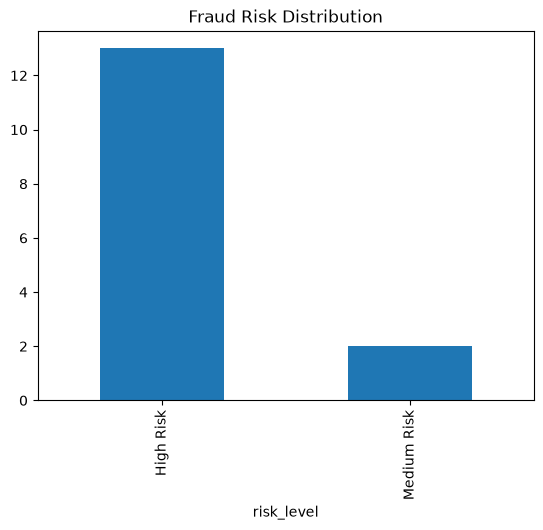

In [38]:
results_df["risk_level"].value_counts().plot(kind="bar")

plt.title("Fraud Risk Distribution")

plt.show()

In [39]:
results_df[["similarity", "fraud_label"]].corr()

,similarity,fraud_label
similarity,1.000000,-0.057726
fraud_label,-0.057726,1.000000


In [40]:
results_df.to_csv("../data/cross_document_similarity_results.csv", index=False)

In [ ]:
high_risk.to_csv("../data/high_risk_claims.csv", index=False)